# MadGraph muon and MCP validation

Compare the cross section and 2x2 geometric acceptance for Standard Model muons and photon-only MCPs with the muon mass.

In [21]:
from pathlib import Path
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MUON_LHE = sorted(Path("/Volumes/HC/DY_Muon_MCPModel/Events").glob("muon_*/unweighted_events.lhe.gz"))
MCP_LHE = sorted(Path("/Volumes/HC/DY_MCP/Events").glob("m0p10566_*/unweighted_events.lhe.gz"))

QCHI = 0.01
E_BEAM = 120.0
M_PROTON = 0.9382720813
Z_DETECTOR = 1040.0

p_beam = np.sqrt(E_BEAM**2 - M_PROTON**2)
boost_beta = p_beam/(E_BEAM + M_PROTON)
boost_gamma = 1/np.sqrt(1 - boost_beta**2)

print(f"Muon files: {len(MUON_LHE)}")
print(f"MCP files: {len(MCP_LHE)}")

Muon files: 1
MCP files: 1


In [22]:
def accepted_2x2(px, py, pz):
    x = px/pz*Z_DETECTOR
    y = py/pz*Z_DETECTOR
    return pz > 0 and -0.70 <= y <= 0.70 and (-0.65 <= x <= -0.05 or 0.05 <= x <= 0.65)

def read_lhe(files, pdg):
    cross_sections, cross_section_errors = [], []
    n_events = n_particles = n_accepted = 0
    angles, rapidities = [], []

    for path in files:
        in_init = in_event = False
        init, event = [], []

        with gzip.open(path, "rt") as source:
            for line in source:
                text = line.strip()

                if text == "<init>":
                    in_init, init = True, []
                    continue
                if text == "</init>":
                    n_processes = int(init[0].split()[-1])
                    process = np.array([[float(x) for x in row.split()[:2]] for row in init[1:1 + n_processes]])
                    cross_sections.append(process[:, 0].sum())
                    cross_section_errors.append(np.sqrt(np.sum(process[:, 1]**2)))
                    in_init = False
                    continue
                if in_init:
                    if text and not text.startswith(("#", "<")):
                        init.append(text)
                    continue

                if text == "<event>":
                    in_event, event = True, []
                    continue
                if text != "</event>":
                    if in_event and text and not text.startswith("<"):
                        event.append(text)
                    continue

                in_event = False
                rows = [row.split() for row in event[1:1 + int(event[0].split()[0])]]
                particles = [row for row in rows if int(row[1]) == 1 and abs(int(row[0])) == pdg]
                if len(particles) != 2:
                    continue

                n_events += 1
                for row in particles:
                    px, py = float(row[6]), float(row[7])
                    pz_cm, energy_cm = float(row[8]), float(row[9])
                    pz = boost_gamma*(pz_cm + boost_beta*energy_cm)
                    energy = boost_gamma*(energy_cm + boost_beta*pz_cm)
                    angles.append(np.arctan2(np.hypot(px, py), pz))
                    rapidities.append(0.5*np.log((energy + pz)/(energy - pz)))
                    n_accepted += accepted_2x2(px, py, pz)
                    n_particles += 1

    cross_sections = np.asarray(cross_sections)
    cross_section_errors = np.asarray(cross_section_errors)
    weights = 1/cross_section_errors**2

    return {
        "runs": len(files),
        "events": n_events,
        "particles": n_particles,
        "accepted": n_accepted,
        "sigma_pb": np.average(cross_sections, weights=weights),
        "sigma_stat_pb": 1/np.sqrt(weights.sum()),
        "angle": np.asarray(angles),
        "rapidity": np.asarray(rapidities),
    }

In [23]:
muon = read_lhe(MUON_LHE, 13)
mcp = read_lhe(MCP_LHE, 31)
print("Finished reading both samples.")

Finished reading both samples.


## Cross section comparison

In [24]:
sigma_mu = muon["sigma_pb"]
sigma_mu_err = muon["sigma_stat_pb"]
sigma_mcp = mcp["sigma_pb"]/QCHI**2
sigma_mcp_err = mcp["sigma_stat_pb"]/QCHI**2
z_sigma = abs(sigma_mu - sigma_mcp)/np.hypot(sigma_mu_err, sigma_mcp_err)

sigma_table = pd.DataFrame({
    "runs": [muon["runs"], mcp["runs"]],
    "sigma_pb": [sigma_mu, sigma_mcp],
    "sigma_stat_pb": [sigma_mu_err, sigma_mcp_err],
}, index=["SM muon", r"MCP / $q_\chi^2$"])

display(sigma_table)
print(f"sigma ratio MCP/muon = {sigma_mcp/sigma_mu:.6f}")
print(f"Z_sigma = {z_sigma:.2f}")

,runs,sigma_pb,sigma_stat_pb
SM muon,1,539.7650,0.031225
MCP / $q_\chi^2$,1,539.8071,0.037025


sigma ratio MCP/muon = 1.000078
Z_sigma = 0.87


## 2x2 geometric acceptance comparison

In [25]:
def acceptance(sample):
    a = sample["accepted"]/sample["particles"]
    error = np.sqrt(a*(1 - a)/sample["particles"])
    return a, error

a_mu, a_mu_err = acceptance(muon)
a_mcp, a_mcp_err = acceptance(mcp)
z_acceptance = abs(a_mu - a_mcp)/np.hypot(a_mu_err, a_mcp_err)

acceptance_table = pd.DataFrame({
    "events": [muon["events"], mcp["events"]],
    "particles": [muon["particles"], mcp["particles"]],
    "accepted": [muon["accepted"], mcp["accepted"]],
    "A_geo": [a_mu, a_mcp],
    "A_geo_stat": [a_mu_err, a_mcp_err],
}, index=["SM muon", "MCP"])

display(acceptance_table)
print(f"A_geo ratio MCP/muon = {a_mcp/a_mu:.6f}")
print(f"Z_acceptance = {z_acceptance:.2f}")

,events,particles,accepted,A_geo,A_geo_stat
SM muon,1000000,2000000,297,0.000149,0.000009
MCP,1000000,2000000,262,0.000131,0.000008


A_geo ratio MCP/muon = 0.882155
Z_acceptance = 1.48


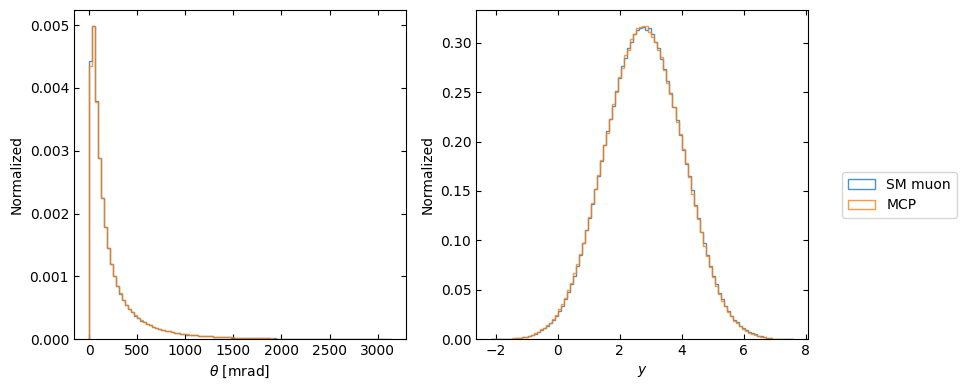

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, variable, label in zip(axes, ["angle", "rapidity"], [r"$\theta$ [mrad]", r"$y$"]):
    mu = muon[variable]*1000 if variable == "angle" else muon[variable]
    chi = mcp[variable]*1000 if variable == "angle" else mcp[variable]
    bins = np.linspace(min(mu.min(), chi.min()), max(mu.max(), chi.max()), 101)
    ax.hist(mu, bins=bins, density=True, histtype="step", linewidth=1.0, alpha=0.8, label="SM muon")
    ax.hist(chi, bins=bins, density=True, histtype="step", linewidth=1.0, alpha=0.8, label="MCP")
    ax.set(xlabel=label, ylabel="Normalized")
    ax.tick_params(direction="in", top=True, right=True)

fig.legend(*axes[0].get_legend_handles_labels(), loc="center left", bbox_to_anchor=(0.84, 0.5))
fig.tight_layout(rect=(0, 0, 0.83, 1))
plt.show()

In [27]:
from scipy.stats import chi2_contingency

for variable in ["angle", "rapidity"]:
    mu = muon[variable]
    chi = mcp[variable]
    bins = np.linspace(min(mu.min(), chi.min()), max(mu.max(), chi.max()), 101)

    n_mu = np.histogram(mu, bins)[0]
    n_chi = np.histogram(chi, bins)[0]
    keep = n_mu + n_chi > 0

    chi2, p, ndf, _ = chi2_contingency(
        np.vstack([n_mu[keep], n_chi[keep]]),
        correction=False
    )

    print(f"{variable}: χ²/ndf = {chi2:.1f}/{ndf} = {chi2/ndf:.3f}, p = {p:.3g}")

angle: χ²/ndf = 234.7/99 = 2.371, p = 4.88e-13
rapidity: χ²/ndf = 313.7/99 = 3.169, p = 3.82e-24
